# Multi-agent training report

Per-learner learning curves and trained-vs-random checks for the CTDE run. Agents are
read from the saved curve, so this works for one agent (`--agents temperature`) or a
joint run (`--agents temperature routing`). Run `python -m training.marl.train --agents ...`
first to produce the artifacts.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "training" / "config.py").exists():
            return candidate
    raise RuntimeError("project root not found (training/config.py)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from env.training_env import ColdChainTrainingEnv
from training.config import COMPARE_SEED, CURVE_CSV, METRIC, env_config
from training.marl.agents import RandomAgent
from training.marl.evaluate import rollout

curve = pd.read_csv(CURVE_CSV)
AGENTS = [c[len("return_"):] for c in curve.columns if c.startswith("return_")]

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
print("trained agents:", AGENTS)

trained agents: ['temperature', 'routing', 'spoilage', 'inventory', 'delivery_0', 'delivery_1', 'delivery_2']


## Learning curves

Per learner: mean greedy return per episode (up = better) and its task metric
(down = better), over training iterations.

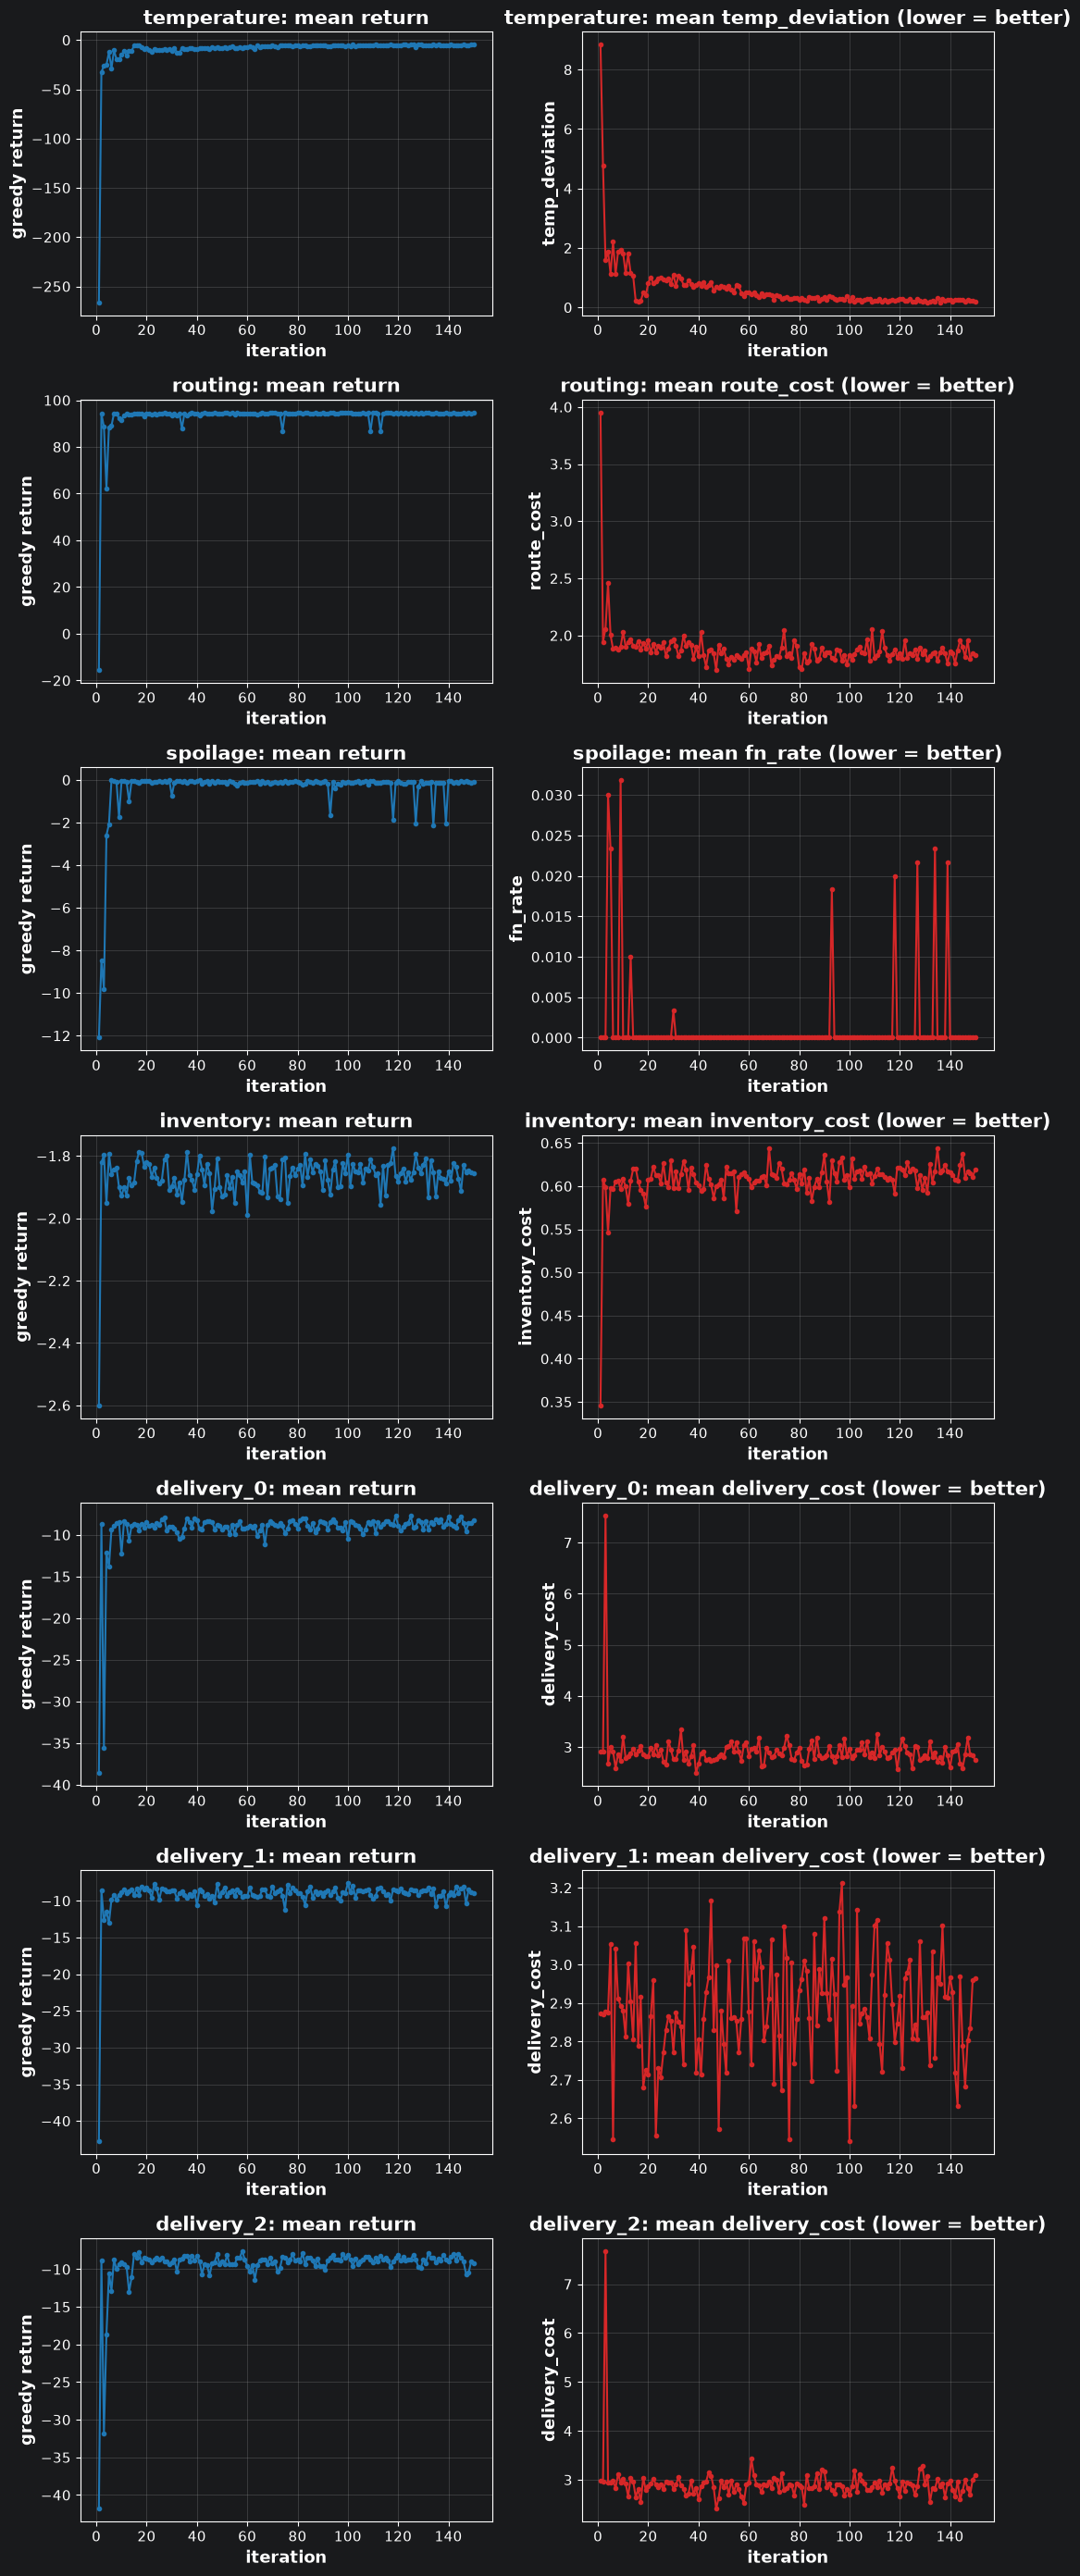

In [2]:
fig, axes = plt.subplots(len(AGENTS), 2, figsize=(11, 4 * len(AGENTS)), squeeze=False)
for i, a in enumerate(AGENTS):
    metric_key, direction = METRIC[a]
    goal = "lower = better" if direction == "min" else "higher = better"
    axes[i][0].plot(curve["iteration"], curve[f"return_{a}"], marker="o", ms=3, color="tab:blue")
    axes[i][0].set(title=f"{a}: mean return", xlabel="iteration", ylabel="greedy return")
    axes[i][1].plot(curve["iteration"], curve[f"{metric_key}_{a}"], marker="o", ms=3, color="tab:red")
    axes[i][1].set(title=f"{a}: mean {metric_key} ({goal})", xlabel="iteration", ylabel=metric_key)
fig.tight_layout()
plt.show()

## Trained vs random

Per learner: deterministic (greedy) trained policy vs a random one on a held-out seed
set, each measured against a **fixed frozen no-op backdrop** (only this agent active).
Same methodology as `training.marl.train._compare` — loading the other agents trained would
suppress the world (e.g. controlled temperature kills spoilage risk) and distort margins.

temperature: trained temp_deviation=0.271  random=12.347  (+98%)
routing: trained route_cost=1.909  random=5.019  (+62%)
spoilage: trained fn_rate=0.033  random=0.220  (+85%)
inventory: trained inventory_cost=0.289  random=1.296  (+78%)
delivery: trained delivery_cost=2.903  random=5.060  (+43%)


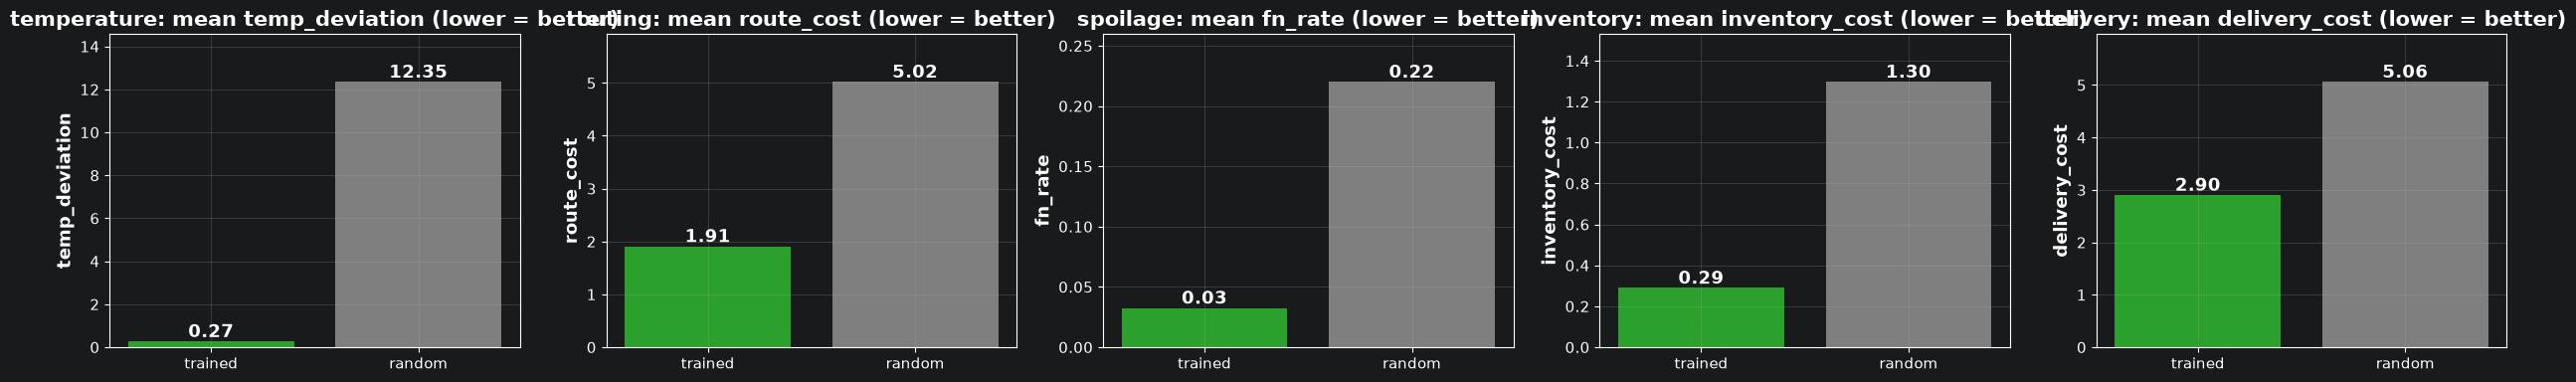

In [3]:
from core.config import DELIVERY_AGENTS
from training.config import build_agents, module_dir

N_EPISODES = 40

# Mirror training.marl.train._compare_block: each block vs a FIXED frozen no-op backdrop,
# swapping only the primary trained<->random. Delivery vehicles form ONE block
# (shared MADDPG group persisted by delivery_0; per-vehicle solo load would be a no-op
# for delivery_1/2 and evaluate untrained actors).
blocks = [(a, [a]) for a in AGENTS if a not in DELIVERY_AGENTS]
delivery = [a for a in AGENTS if a in DELIVERY_AGENTS]
if delivery:
    blocks.append(("delivery", delivery))

fig, axes = plt.subplots(1, len(blocks), figsize=(5 * len(blocks), 4), squeeze=False)
for i, (name, block) in enumerate(blocks):
    metric_key, direction = METRIC[block[0]]
    goal = "lower = better" if direction == "min" else "higher = better"

    env = ColdChainTrainingEnv(env_config(COMPARE_SEED, block))
    trained = build_agents(env, block)
    trained[block[0]].load(module_dir(block[0]))
    trained_m = sum(rollout(env, trained, a, N_EPISODES, metric_key)[1] for a in block) / len(block)

    env = ColdChainTrainingEnv(env_config(COMPARE_SEED, block))
    rand = build_agents(env, block)
    for a in block:
        rand[a] = RandomAgent(env.action_space(a))
    random_m = sum(rollout(env, rand, a, N_EPISODES, metric_key)[1] for a in block) / len(block)

    better = (random_m - trained_m) if direction == "min" else (trained_m - random_m)
    margin = better / abs(random_m) if random_m else float("nan")
    print(f"{name}: trained {metric_key}={trained_m:.3f}  random={random_m:.3f}  ({margin:+.0%})")

    ax = axes[0][i]
    ax.bar(["trained", "random"], [trained_m, random_m], color=["tab:green", "tab:gray"])
    ax.set(title=f"{name}: mean {metric_key} ({goal})", ylabel=metric_key)
    ax.margins(y=0.18)
    for j, v in enumerate([trained_m, random_m]):
        ax.text(j, v, f"{v:.2f}", ha="center", va="bottom", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Delivery coordination\n\nVehicles must spread across delivery slots (paper Alg 5 intention buffer): conflict rate and SLA-violation rate should be near zero for the trained group, high for random.

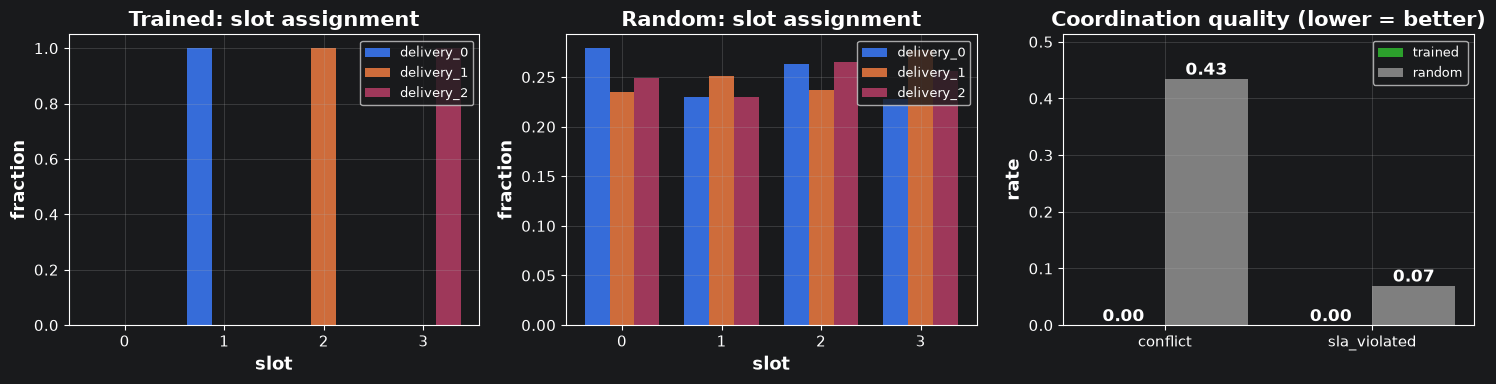

trained: conflict=0.000 sla=0.000  |  random: conflict=0.435 sla=0.070


In [4]:
import numpy as np


def delivery_stats(agents, env, n_episodes=30):
    slots = {a: [] for a in delivery}
    conflict, sla = [], []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            actions = {a: agents[a].act(obs[a], explore=False) for a in agents}
            for a in delivery:
                slots[a].append(int(actions[a]))
            obs, _, term, trunc, infos = env.step(actions)
            conflict.append(np.mean([infos[a]["conflict"] for a in delivery]))
            sla.append(np.mean([infos[a]["sla_violated"] for a in delivery]))
            done = term["__all__"] or trunc["__all__"]
    return slots, float(np.mean(conflict)), float(np.mean(sla))

env = ColdChainTrainingEnv(env_config(COMPARE_SEED, delivery))
trained = build_agents(env, delivery)
trained[delivery[0]].load(module_dir(delivery[0]))
t_slots, t_conf, t_sla = delivery_stats(trained, env)

env = ColdChainTrainingEnv(env_config(COMPARE_SEED, delivery))
rand = build_agents(env, delivery)
for a in delivery:
    rand[a] = RandomAgent(env.action_space(a))
r_slots, r_conf, r_sla = delivery_stats(rand, env)

from core.config import N_DELIVERY_WINDOWS

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
width = 0.25
x = np.arange(N_DELIVERY_WINDOWS)
for k, a in enumerate(delivery):
    counts = np.bincount(t_slots[a], minlength=N_DELIVERY_WINDOWS)
    axes[0].bar(x + (k - 1) * width, counts / counts.sum(), width, label=a)
axes[0].set(title="Trained: slot assignment", xlabel="slot", ylabel="fraction", xticks=x)
axes[0].legend(fontsize=9)

for k, a in enumerate(delivery):
    counts = np.bincount(r_slots[a], minlength=N_DELIVERY_WINDOWS)
    axes[1].bar(x + (k - 1) * width, counts / counts.sum(), width, label=a)
axes[1].set(title="Random: slot assignment", xlabel="slot", ylabel="fraction", xticks=x)
axes[1].legend(fontsize=9)

pairs = [("conflict", t_conf, r_conf), ("sla_violated", t_sla, r_sla)]
xp = np.arange(len(pairs))
axes[2].bar(xp - 0.2, [p[1] for p in pairs], 0.4, label="trained", color="tab:green")
axes[2].bar(xp + 0.2, [p[2] for p in pairs], 0.4, label="random", color="tab:gray")
axes[2].set(title="Coordination quality (lower = better)", xticks=xp,
            xticklabels=[p[0] for p in pairs], ylabel="rate")
axes[2].margins(y=0.18)
for xi, (_, tv, rv) in zip(xp, pairs):
    axes[2].text(xi - 0.2, tv, f"{tv:.2f}", ha="center", va="bottom", fontweight="bold")
    axes[2].text(xi + 0.2, rv, f"{rv:.2f}", ha="center", va="bottom", fontweight="bold")
axes[2].legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"trained: conflict={t_conf:.3f} sla={t_sla:.3f}  |  random: conflict={r_conf:.3f} sla={r_sla:.3f}")